In [2]:
import pandas as pd

df = pd.read_csv('order_history_kaggle_data.csv')
df['Items in order'].head()


0    1 x Grilled Chicken Jamaican Tender, 1 x Grill...
1    1 x Peri Peri Fries, 1 x Fried Chicken Angara ...
2                1 x Bone in Peri Peri Grilled Chicken
3    1 x Fried Chicken Ghostbuster Tender, 1 x Anga...
4    1 x Peri Peri Krispers, 1 x Fried Chicken Anga...
Name: Items in order, dtype: object

In [3]:
def parse_items(order_str):
    if pd.isna(order_str):
        return []
    items = order_str.split(', ')
    return [item.strip() for item in items]

df['Parsed Items'] = df['Items in order'].apply(parse_items)
df['Parsed Items'].head()


0    [1 x Grilled Chicken Jamaican Tender, 1 x Gril...
1    [1 x Peri Peri Fries, 1 x Fried Chicken Angara...
2              [1 x Bone in Peri Peri Grilled Chicken]
3    [1 x Fried Chicken Ghostbuster Tender, 1 x Ang...
4    [1 x Peri Peri Krispers, 1 x Fried Chicken Ang...
Name: Parsed Items, dtype: object

In [4]:
def count_items(parsed_list):
    total = 0
    for item in parsed_list:
        try:
            qty = int(item.split(' x ')[0])
        except:
            qty = 1
        total += qty
    return total

df['Total Items'] = df['Parsed Items'].apply(count_items)


In [5]:
def extract_item_names(parsed_list):
    item_names = []
    for item in parsed_list:
        parts = item.split(' x ')
        if len(parts) == 2:
            name = parts[1].lower().strip()
            item_names.append(name)
        else:
            item_names.append(item.lower().strip())
    return item_names

df['Cleaned Item Names'] = df['Parsed Items'].apply(extract_item_names)


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

df['Text for Vector'] = df['Cleaned Item Names'].apply(lambda x: ', '.join(x))

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['Text for Vector'])


In [7]:
from sklearn.cluster import KMeans

# Ensure X matches the filtered rows in df
X_filtered = X[df.index]

kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_filtered)


In [8]:
for i in range(5):
    print(f"\nCluster {i}:")
    sample_orders = df[df['Cluster'] == i]['Items in order'].sample(5, random_state=1)
    print(sample_orders.to_string(index=False))



Cluster 0:
1 x Bone in Smoky Bbq Grilled Chicken, 1 x Bone...
1 x Grilled Chicken Jamaican Tender, 1 x Bone i...
2 x Grilled Chicken Jamaican Tangdi, 2 x Fried ...
1 x Bone in Smoky Bbq Grilled Chicken, 1 x Gril...
1 x Bone in Peri Peri Grilled Chicken, 1 x Gril...

Cluster 1:
                          1 x Bageecha Pizza
1 x Bageecha Pizza, 1 x Desi Pepperoni Pizza
                          1 x Bageecha Pizza
      1 x Mushroom Pizza, 1 x Bageecha Pizza
                          2 x Bageecha Pizza

Cluster 2:
                       1 x Bellpepper Onion Pizza
1 x Just Pepperoni Pide, 1 x Tripple Cheese Pizza
                       1 x Peri Peri Chicken Melt
                            2 x Dirty Saucy Fries
                        2 x Jamaican Chicken Melt

Cluster 3:
1 x Peanut Butter Chocolate Pide, 1 x Murgh Amr...
1 x Chilli Cheese Garlic Bread, 1 x Bageecha Pi...
1 x Chilli Cheese Garlic Bread, 1 x Bageecha Pizza
1 x Bageecha Pizza, 1 x Chilli Cheese Garlic Bread
1 x Bacon Pepperon

In [9]:
df = df.dropna(subset=['KPT duration (minutes)'])
df['KPT duration (minutes)'] = pd.to_numeric(df['KPT duration (minutes)'], errors='coerce')  # Chuyển thành số nếu chưa
df = df.dropna(subset=['KPT duration (minutes)'])  # Loại bỏ dòng không chuyển được


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Gộp vector hóa + số lượng + cluster
# Ensure features matches the filtered rows in df
# Ensure features matches the filtered rows in df
features = pd.DataFrame(X_filtered[df.index].toarray())  # Filter X_filtered to match df
features['Total Items'] = df['Total Items'].values
features['Cluster'] = df['Cluster'].values

target = df['KPT duration (minutes)'].values

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)


In [11]:
# Ensure all column names in features are strings
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [12]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MAE: {mae:.2f}')
print(f'R² score: {r2:.2f}')


MAE: 3.87
R² score: 0.17


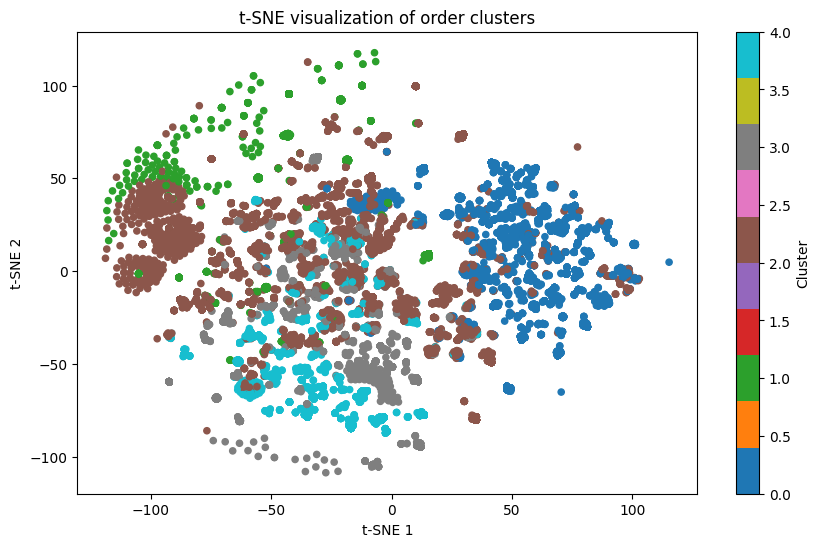

In [13]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(X_filtered[df.index].toarray())  # Align X_filtered with df

plt.figure(figsize=(10, 6))
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=df['Cluster'], cmap='tab10', s=20)
plt.title('t-SNE visualization of order clusters')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.colorbar(label='Cluster')
plt.show()


In [14]:
# Tính thời gian KPT trung bình cho từng cụm
kpt_per_cluster = df.groupby('Cluster')['KPT duration (minutes)'].mean()

# In thời gian KPT trung bình cho từng cụm
print("Thời gian KPT trung bình cho các cụm:")
print(kpt_per_cluster)

# In các mục trong mỗi cụm
for cluster_id in range(kmeans.n_clusters):
    print(f"\nCụm {cluster_id} chứa:")
    items_in_cluster = df[df['Cluster'] == cluster_id]['Items in order'].head(10)  # Lấy 10 mục đầu tiên
    print(items_in_cluster.to_string(index=False))

Thời gian KPT trung bình cho các cụm:
Cluster
0    17.994269
1    17.194363
2    17.373815
3    16.237608
4    17.114004
Name: KPT duration (minutes), dtype: float64

Cụm 0 chứa:
1 x Grilled Chicken Jamaican Tender, 1 x Grille...
1 x Peri Peri Fries, 1 x Fried Chicken Angara T...
             1 x Bone in Peri Peri Grilled Chicken
1 x Fried Chicken Ghostbuster Tender, 1 x Angar...
1 x Peri Peri Krispers, 1 x Fried Chicken Angar...
1 x Grilled Chicken Jamaican Tangdi, 1 x Bone i...
              1 x Bone in Jamaican Grilled Chicken
                1 x Bone in Angara Grilled Chicken
  1 x Fried Chicken Angara Tender, 1 x Angara Rice
              1 x Grilled Chicken Peri Peri Tangdi

Cụm 1 chứa:
                                1 x Bageecha Pizza
                                1 x Bageecha Pizza
   1 x All About Chicken Pizza, 1 x Bageecha Pizza
             1 x Bageecha Pizza, 1 x Herbed Potato
             2 x Herbed Potato, 1 x Bageecha Pizza
1 x Mushroom Pizza, 1 x Bageecha Pizza, 1 x

In [ ]:
# Lọc các đơn hàng có Rider wait time lớn hơn 8 phút
filtered_df = df[df['Rider wait time (minutes)'] > 8]

# Reset the index of filtered_df to align with y_test and y_pred
filtered_df = filtered_df.reset_index()

# Ensure the indices in filtered_df align with y_test and y_pred
valid_indices = filtered_df['index'][filtered_df['index'] < len(y_test)]

# Lấy các giá trị thực tế và dự đoán tương ứng
y_test_filtered = y_test[valid_indices]
y_pred_filtered = y_pred[valid_indices]

# Tính toán chênh lệch giữa giá trị thực tế và dự đoán
difference = abs(y_test_filtered - y_pred_filtered)

# Kiểm tra nếu chênh lệch nằm trong khoảng 5 phút
accepted = (difference >= 0) & (difference <= 5)

# In kết quả
print(f"Số lượng đơn hàng được chấp nhận: {accepted.sum()}")
print(f"Số lượng đơn hàng không được chấp nhận: {len(accepted) - accepted.sum()}")

# Bỏ cột Total và chỉ hiển thị KPT dự đoán từ phân cụm cluster và KPT thực tế
random_sample = filtered_df.sample(10, random_state=42)

# Hiển thị KPT dự đoán từ phân cụm cluster và KPT thực tế
for cluster_id in range(kmeans.n_clusters):
    print(f"\nCluster {cluster_id}:")
    cluster_kpt_predicted = kpt_per_cluster[cluster_id]
    cluster_orders = random_sample[random_sample['Cluster'] == cluster_id]
    for _, order in cluster_orders.iterrows():
        actual_kpt = order['KPT duration (minutes)']
        difference = abs(actual_kpt - cluster_kpt_predicted)
        status = "Accepted" if 0 <= difference <= 8 else "Unaccepted"
        print(f"Order ID: {order['Order ID']}, Predicted KPT: {cluster_kpt_predicted:.2f}, Actual KPT: {actual_kpt:.2f}, Difference: {difference:.2f}, Status: {status}")



Số lượng đơn hàng được chấp nhận: 726
Số lượng đơn hàng không được chấp nhận: 247

Cluster 0:
Order ID: 6149979442, Predicted KPT: 17.99, Actual KPT: 15.00, Difference: 2.99, Status: Accepted

Cluster 1:
Order ID: 6388072479, Predicted KPT: 17.19, Actual KPT: 25.73, Difference: 8.54, Status: Unaccepted

Cluster 2:
Order ID: 6533009485, Predicted KPT: 17.37, Actual KPT: 15.02, Difference: 2.35, Status: Accepted
Order ID: 6340408189, Predicted KPT: 17.37, Actual KPT: 48.80, Difference: 31.43, Status: Unaccepted
Order ID: 6497624145, Predicted KPT: 17.37, Actual KPT: 16.08, Difference: 1.29, Status: Accepted
Order ID: 6308967625, Predicted KPT: 17.37, Actual KPT: 17.32, Difference: 0.05, Status: Accepted
Order ID: 6232910960, Predicted KPT: 17.37, Actual KPT: 14.44, Difference: 2.93, Status: Accepted

Cluster 3:

Cluster 4:
Order ID: 6182901667, Predicted KPT: 17.11, Actual KPT: 12.90, Difference: 4.21, Status: Accepted
Order ID: 6180099703, Predicted KPT: 17.11, Actual KPT: 17.18, Differ

In [24]:

filtered_df['new_kpt'] = filtered_df['KPT duration (minutes)'] - 8
# Lọc các đơn hàng có difference > 8
filtered_df = filtered_df[filtered_df['Difference'] > 5]

# Align y_pred_filtered with filtered_df using valid_indices
aligned_y_pred_filtered = pd.Series(y_pred_filtered, index=valid_indices)

# Ensure valid_indices are present in filtered_df
valid_indices_in_filtered_df = filtered_df.index.intersection(valid_indices)

# So sánh new_kpt với predicted_kpt
filtered_df = filtered_df.loc[valid_indices_in_filtered_df]  # Ensure filtered_df matches valid_indices
filtered_df['Difference'] = filtered_df['new_kpt'] - aligned_y_pred_filtered.loc[valid_indices_in_filtered_df].values

# Chỉ chấp nhận đơn hàng nếu chênh lệch nhỏ hơn hoặc bằng 8 phút
filtered_df['Accepted'] = filtered_df['Difference'].abs() <= 5

# Đếm số lượng đơn hàng được chấp nhận
accepted_after = filtered_df['Accepted'].sum()
unaccepted_after = len(filtered_df) - accepted_after

# Lọc các đơn hàng có Order Ready Marked là "Correctly"
filtered_df = filtered_df[filtered_df['Order Ready Marked'] == 'Correctly']

# In thử 10 đơn hàng không được chấp nhận sau khi trừ 8 phút và có Order Ready Marked là "Correctly"
print("Tổng đơn hàng không được chấp nhận sau khi trừ 8 phút")
print(unaccepted_after.sum())
print("Chi tiết 10 đơn hàng không được chấp nhận sau khi trừ 8 phút và có Order Ready Marked là 'Correctly':")
print(filtered_df[~filtered_df['Accepted']].head(10).to_string(index=False))


KeyError: 'Difference'